# 02. 전처리 — `preprocessing_plan.tex` 구현

EDA 최종본에서 도출한 전처리 계획을 실행한다. 두 출력 경로를 생성한다.

- **Tabular** (LightGBM 주 모델): raw + 조건정규화 `z_` + rolling → `data/processed/*.csv`
- **Sequence** (LSTM 병행): 윈도우 텐서 + 마스크 → `data/processed/seq/*.npz`

두 경로는 **S1–S5(로드·라벨·condition_id·센서 분류·조건 정규화)를 공유**하고 특징 구성에서 분기한다.

핵심 설계 (계획서 근거):
- RUL clip 125 (piecewise-linear)  ·  `condition_id`로 setting 통합 (`+0.0`으로 −0.0 제거)
- 센서 4분류: 상수/조건지시자(제거) · 근사상수(유지+방어) · 열화가능(raw+z+rolling)
- 조건 정규화: train fit → test transform, σ-floor(NaN 방지) + z-clip ±10(blowup)
- 누수 차단: total_life/RUL_raw/relative_cycle 제외, 엔진 단위 분리, rolling은 과거만
- 검증 assertion V1–V12

### S0. 준비 — 경로·설정·로더

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.model_selection import GroupShuffleSplit

sns.set_theme(style="whitegrid", font_scale=0.9)
try:
    plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
except Exception: pass

for cand in [Path.cwd(), *Path.cwd().parents]:
    if (cand / "data" / "raw").exists(): ROOT = cand; break
else: raise FileNotFoundError("data/raw 없음")
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
SEQ  = PROC / "seq"; SEQ.mkdir(parents=True, exist_ok=True)
FIG  = ROOT / "reports" / "figures" / "preprocessing"; FIG.mkdir(parents=True, exist_ok=True)

# ---- 하이퍼파라미터 (계획서 §10) ----
CLIP       = 125                 # RUL clip 상한
COND_ROUND = {"set1":0,"set2":2,"set3":0}
W_SHORT, W_LONG = 5, 20          # rolling 윈도우
EPS        = 1e-2                # σ-floor 계수
ZCLIP      = 10.0                # z-clip 한계 (정상 센서 max|z|≈8.3 → ±10)
L_SEQ      = 30                  # LSTM 윈도우 길이
SEED       = 42
FD_LIST    = ["FD001","FD002","FD003","FD004"]

SETTINGS = ["set1","set2","set3"]; SENSORS = [f"s{i}" for i in range(1,22)]
COLS = ["unit","cycle"]+SETTINGS+SENSORS
def load_train(fd): return pd.read_csv(RAW/f"train_{fd}.txt", sep=r"\s+", header=None, names=COLS)
def load_test(fd):  return pd.read_csv(RAW/f"test_{fd}.txt",  sep=r"\s+", header=None, names=COLS)
def load_rul(fd):   return pd.read_csv(RAW/f"RUL_{fd}.txt", sep=r"\s+", header=None, names=["true_RUL"])["true_RUL"].values
print("ROOT:", ROOT)

ROOT: C:\Users\user\Desktop\Team_YH\Purdue_Agent\aircraft-engine-rul-scheduling


### S2–S3. RUL 라벨 & `condition_id` (setting 통합)

`RUL = min(total_life − cycle, 125)`. condition_id는 반올림 후 `+0.0`으로 −0.0을 제거한다
(안 하면 FD001/FD003 조건이 2개로 잘못 잡힘 — 계획서 §6.1).

In [2]:
def add_labels(df, clip=CLIP):
    df = df.sort_values(["unit","cycle"]).copy()
    life = df.groupby("unit")["cycle"].transform("max")
    df["total_life"]     = life                    # (분석용, 저장 제외)
    df["RUL_raw"]        = life - df["cycle"]       # (분석용, 저장 제외)
    df["relative_cycle"] = df["cycle"] / life       # (분석용, 저장 제외)
    df["RUL"]            = df["RUL_raw"].clip(upper=clip)
    r = df[SETTINGS].round(COND_ROUND) + 0.0        # −0.0 제거
    df["condition_id"] = (r.set1.astype(int).astype(str)+"|"+
                          r.set2.map(lambda v: f"{v:.2f}")+"|"+
                          r.set3.astype(int).astype(str))
    return df

# 전역 조건 체계 (네 서브셋 공통 6개, FD001/FD003 = C1)
GLOBAL_CONDS = sorted(set().union(*[set(add_labels(load_train(fd))["condition_id"].unique()) for fd in FD_LIST]))
COND_INDEX = {c:i for i,c in enumerate(GLOBAL_CONDS)}
print("전역 condition (C1..C%d):" % len(GLOBAL_CONDS)); [print(f"  C{i+1}: {c}") for i,c in enumerate(GLOBAL_CONDS)]

# V1: 조건 수 검증
for fd in FD_LIST:
    nc = add_labels(load_train(fd))["condition_id"].nunique()
    exp = 1 if fd in ("FD001","FD003") else 6
    assert nc == exp, f"[V1] {fd} 조건 수 {nc} != {exp}"
print("\n[V1] 조건 수 OK  (FD001/FD003=1, FD002/FD004=6)")

전역 condition (C1..C6):
  C1: 0|0.00|100
  C2: 10|0.25|100
  C3: 20|0.70|100
  C4: 25|0.62|60
  C5: 35|0.84|100
  C6: 42|0.84|100



[V1] 조건 수 OK  (FD001/FD003=1, FD002/FD004=6)


### S4. 센서 4분류 (FD별 train 기준)

- **상수** `nunique≤1` → 제거   · **조건지시자** 모든 조건에서 조건내 `nunique≤1` → 제거
- **근사상수** `dominant≥0.95` 또는 `std<0.01` → 유지(방어)   · **열화가능** 나머지

In [3]:
def classify_sensors(train):
    const, ind, near = [], [], []
    for s in SENSORS:
        if train[s].nunique() <= 1: const.append(s); continue
        if (train.assign(c=add_labels(train)["condition_id"]).groupby("c")[s].nunique() <= 1).all():
            ind.append(s); continue
        if train[s].value_counts(normalize=True).iloc[0] >= 0.95 or train[s].std() < 0.01:
            near.append(s)
    feature = [s for s in SENSORS if s not in const and s not in ind]  # 열화가능(근사상수 포함)
    return {"constant":const, "indicator":ind, "near_constant":near, "feature":feature}

rows=[]
CLASS={}
for fd in FD_LIST:
    c = classify_sensors(load_train(fd)); CLASS[fd]=c
    rows.append({"set":fd, "상수":len(c["constant"]), "조건지시자":len(c["indicator"]),
                 "근사상수":",".join(c["near_constant"]) or "-", "열화가능 n":len(c["feature"])})
    print(f"{fd}: 상수{c['constant']} 지시{c['indicator']} 근사{c['near_constant']} 열화가능={len(c['feature'])}")
display(pd.DataFrame(rows))

FD001: 상수['s1', 's5', 's10', 's16', 's18', 's19'] 지시[] 근사['s6'] 열화가능=15


FD002: 상수[] 지시['s1', 's5', 's18', 's19'] 근사['s16'] 열화가능=17


FD003: 상수['s1', 's5', 's16', 's18', 's19'] 지시[] 근사['s10'] 열화가능=16


FD004: 상수[] 지시['s1', 's5', 's18', 's19'] 근사['s16'] 열화가능=17


,set,상수,조건지시자,근사상수,열화가능 n
0,FD001,6,0,s6,15
1,FD002,0,4,s16,17
2,FD003,5,0,s10,16
3,FD004,0,4,s16,17


### S5. 조건 정규화 `z_` (train fit → transform)

`z = clip((s − μ_cond)/σ̃_cond, ±10)`,  `σ̃ = max(σ_cond, ε·σ_global, 1e-6)`.
floor는 σ_cond=0의 NaN을 막고, clip은 미세 σ의 blowup을 막는다. 통계는 **train에서만** 추정.

In [4]:
def fit_cond_stats(train, sensors):
    stats = {}
    for s in sensors:
        g = train.groupby("condition_id")[s]
        mu = g.mean(); sd = g.std().fillna(0.0)
        floor = max(EPS*train[s].std(), 1e-6)
        sd_t = sd.clip(lower=floor)
        stats[s] = {"mu":mu.to_dict(), "sd":sd_t.to_dict(), "global_floor":float(floor)}
    return stats

def apply_z(df, sensors, stats):
    out = df.copy()
    for s in sensors:
        mu = df["condition_id"].map(stats[s]["mu"])
        sd = df["condition_id"].map(stats[s]["sd"]).fillna(stats[s]["global_floor"])
        mu = mu.fillna(df[s].mean())
        out["z_"+s] = np.clip((df[s]-mu)/sd, -ZCLIP, ZCLIP)
    return out

### S6. Rolling 특징 (z_ 위, 과거만) — Tabular 경로
`ma5, sd5, ma20, sd20, dl20, sl20` (센서당 6개). 미래 미사용(`min_periods`, `shift`).

In [5]:
def rolling_slope(y, w):
    y = np.asarray(y, float); n = len(y); out = np.zeros(n)
    if n < 2: return out
    xf = np.arange(w); xb = xf.mean(); denom = ((xf-xb)**2).sum()
    if n >= w:
        Y = sliding_window_view(y, w); out[w-1:] = (Y*(xf-xb)).sum(1)/denom
    for i in range(1, min(w-1, n)):
        xx = np.arange(i+1); b = xx.mean(); dn = ((xx-b)**2).sum()
        out[i] = ((y[:i+1]-y[:i+1].mean())*(xx-b)).sum()/dn if dn>0 else 0.0
    return out

def add_rolling(df, zcols):
    df = df.sort_values(["unit","cycle"]).copy(); gb = df.groupby("unit")
    add = {}
    for w in (W_SHORT, W_LONG):
        for c in zcols:
            add[f"{c}_ma{w}"] = gb[c].rolling(w, min_periods=1).mean().reset_index(level=0, drop=True)
            add[f"{c}_sd{w}"] = gb[c].rolling(w, min_periods=1).std().reset_index(level=0, drop=True).fillna(0.0)
    for c in zcols:
        add[f"{c}_dl{W_LONG}"] = gb[c].diff(W_LONG).fillna(0.0)
        add[f"{c}_sl{W_LONG}"] = gb[c].transform(lambda s: pd.Series(rolling_slope(s.to_numpy(), W_LONG), index=s.index))
    return df.assign(**add)

### S7–S9. Tabular 조립·저장 + 검증 (V2·V5·V9·V10)

In [6]:
META = ["unit","cycle","dataset_id","condition_id"]
LEAK = ["total_life","RUL_raw","relative_cycle"]

def build_tabular(fd):
    tr = add_labels(load_train(fd)); tr["dataset_id"] = fd
    te = add_labels(load_test(fd));  te["dataset_id"] = fd
    feat = CLASS[fd]["feature"]
    stats = fit_cond_stats(tr, feat)                 # train fit
    tr = apply_z(tr, feat, stats); te = apply_z(te, feat, stats)
    zc = [f"z_{s}" for s in feat]
    tr = add_rolling(tr, zc); te = add_rolling(te, zc)
    roll = [c for c in tr.columns if any(c.startswith(f"z_{s}_") for s in feat)]
    fcols = feat + zc + roll
    keep_tr = META + fcols + ["RUL"]; keep_te = META + fcols
    return tr[keep_tr].copy(), te[keep_te].copy(), stats, fcols

MANIFEST = {}
for fd in FD_LIST:
    trf, tef, stats, fcols = build_tabular(fd)
    trf.to_csv(PROC/f"train_features_{fd}.csv", index=False)
    tef.to_csv(PROC/f"test_features_{fd}.csv", index=False)
    # ---- 검증 ----
    xf = [c for c in fcols]
    stds = trf[xf].std()
    assert (stds > 1e-8).all(), f"[V2] {fd} 퇴화 특징: {list(stds[stds<=1e-8].index)[:5]}"
    zcols = [c for c in xf if c.startswith("z_") and c.count('_')==1]
    assert trf[zcols].abs().to_numpy().max() <= ZCLIP+1e-6, f"[V3] {fd} z clip 위반"
    assert not any(c in trf.columns for c in LEAK), f"[V5] {fd} 누수 컬럼"
    assert trf["RUL"].between(0, CLIP).all(), f"[V9] {fd} RUL 범위"
    assert not any(c in trf.columns for c in [f"z_{s}" for s in CLASS[fd]["indicator"]]), f"[V10] {fd} 조건지시자 z"
    assert trf.isna().sum().sum()==0, f"[V4] {fd} NaN"
    MANIFEST[fd] = {"n_feature_sensors":len(CLASS[fd]["feature"]), "n_features":len(fcols),
                    "sensor_derived_8n":8*len(CLASS[fd]["feature"]),
                    "classification":{k:CLASS[fd][k] for k in ("constant","indicator","near_constant","feature")},
                    "feature_cols":fcols, "condition_count":int(add_labels(load_train(fd))["condition_id"].nunique())}
    print(f"{fd}: train {trf.shape} test {tef.shape} | 센서파생 8n={8*len(CLASS[fd]['feature'])} 총특징={len(fcols)}  [V2,V3,V4,V5,V9,V10 OK]")

(PROC/"feature_manifest.json").write_text(json.dumps(MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nsaved feature_manifest.json")

FD001: train (20631, 125) test (13096, 124) | 센서파생 8n=120 총특징=120  [V2,V3,V4,V5,V9,V10 OK]


FD002: train (53759, 141) test (33991, 140) | 센서파생 8n=136 총특징=136  [V2,V3,V4,V5,V9,V10 OK]


FD003: train (24720, 133) test (16596, 132) | 센서파생 8n=128 총특징=128  [V2,V3,V4,V5,V9,V10 OK]


FD004: train (61249, 141) test (41214, 140) | 센서파생 8n=136 총특징=136  [V2,V3,V4,V5,V9,V10 OK]

saved feature_manifest.json


### S8. 엔진 단위 분리 (V6)

In [7]:
def unit_split(df, test_size=0.25, seed=SEED):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tr, va = next(gss.split(df, groups=df["unit"]))
    return df.iloc[tr], df.iloc[va]

d = pd.read_csv(PROC/"train_features_FD001.csv")
tr, va = unit_split(d)
assert not (set(tr["unit"]) & set(va["unit"])), "[V6] 엔진 겹침"
print(f"[V6] FD001 train {tr['unit'].nunique()} / valid {va['unit'].nunique()} 엔진, 겹침 0 OK")

[V6] FD001 train 75 / valid 25 엔진, 겹침 0 OK


### V8. 미래 미사용 단위 테스트 (rolling 누수 검사)

In [8]:
# 인위적 시퀀스: 마지막 시점에 스파이크. t 이전 rolling 값이 스파이크 후에도 불변이어야 함.
base = pd.DataFrame({"unit":1, "cycle":np.arange(1,41), "z_x":np.zeros(40)})
r1 = add_rolling(base.copy(), ["z_x"])
spk = base.copy(); spk.loc[spk.cycle==40, "z_x"] = 100.0
r2 = add_rolling(spk, ["z_x"])
before = spk.cycle < 40 - W_LONG           # 스파이크가 윈도우에 안 들어오는 이른 시점
assert np.allclose(r1.loc[before,"z_x_ma20"], r2.loc[before,"z_x_ma20"]), "[V8] 미래 누수!"
print("[V8] rolling 미래 미사용 OK — 마지막 스파이크가 과거 특징을 바꾸지 않음")

[V8] rolling 미래 미사용 OK — 마지막 스파이크가 과거 특징을 바꾸지 않음


### 그림 — 전처리 근거 시각화

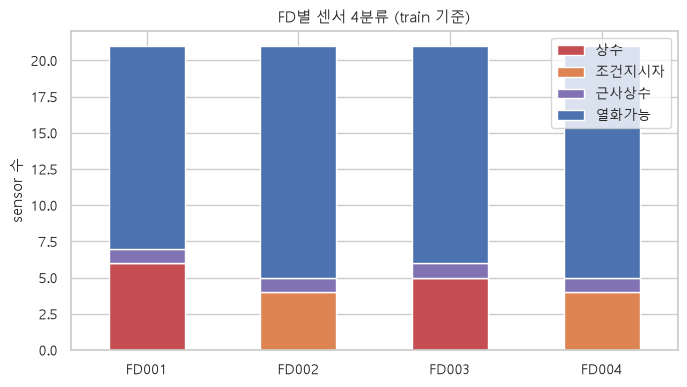

In [9]:
# F1. 센서 4분류
cc = pd.DataFrame({fd:{"상수":len(CLASS[fd]["constant"]),"조건지시자":len(CLASS[fd]["indicator"]),
                       "근사상수":len(CLASS[fd]["near_constant"]),
                       "열화가능":len(CLASS[fd]["feature"])-len(CLASS[fd]["near_constant"])} for fd in FD_LIST}).T
ax = cc[["상수","조건지시자","근사상수","열화가능"]].plot(kind="bar", stacked=True, figsize=(7,4),
        color=["#C44E52","#DD8452","#8172B3","#4C72B0"])
ax.set_ylabel("sensor 수"); ax.set_title("FD별 센서 4분류 (train 기준)"); ax.tick_params(axis="x",rotation=0)
plt.tight_layout(); plt.savefig(FIG/"P1_sensor_classification.png", dpi=110, bbox_inches="tight"); plt.show()

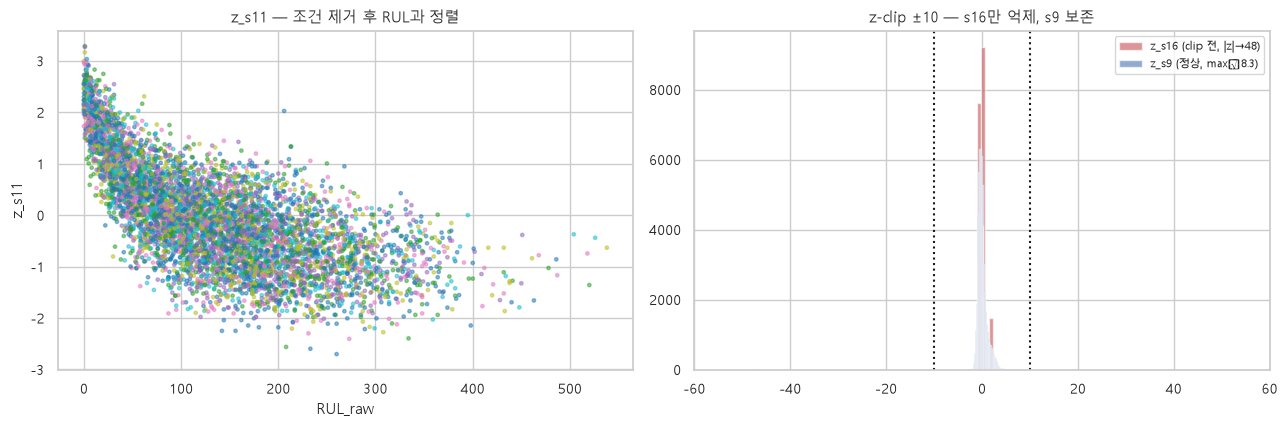

In [10]:
# F2. 조건 정규화 + z-clip 효과 (FD004)
tr = add_labels(load_train("FD004")); feat = CLASS["FD004"]["feature"]
stats = fit_cond_stats(tr, feat); trz = apply_z(tr, feat, stats)
fig, ax = plt.subplots(1,2, figsize=(13,4.4))
# (a) s11 raw vs z RUL 정렬
samp = trz.sample(6000, random_state=SEED); col = pd.factorize(samp["condition_id"])[0]
ax[0].scatter(samp["RUL_raw"], samp["z_s11"], c=col, cmap="tab10", s=6, alpha=0.5)
ax[0].set_xlabel("RUL_raw"); ax[0].set_ylabel("z_s11"); ax[0].set_title("z_s11 — 조건 제거 후 RUL과 정렬")
# (b) z-clip: s16(병리) vs s9(정상) 분포
ax[1].hist(np.clip((tr["s16"]-tr.groupby("condition_id")["s16"].transform("mean")) /
           tr.groupby("condition_id")["s16"].transform("std").replace(0,np.nan), -60,60).dropna(),
           bins=60, alpha=0.6, label="z_s16 (clip 전, |z|→48)", color="#C44E52")
ax[1].hist(trz["z_s9"], bins=60, alpha=0.6, label="z_s9 (정상, max≈8.3)", color="#4C72B0")
ax[1].axvline(ZCLIP, ls=":", c="k"); ax[1].axvline(-ZCLIP, ls=":", c="k")
ax[1].set_xlim(-60,60); ax[1].set_title(f"z-clip ±{ZCLIP:.0f} — s16만 억제, s9 보존"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"P2_condition_norm_clip.png", dpi=110, bbox_inches="tight"); plt.show()

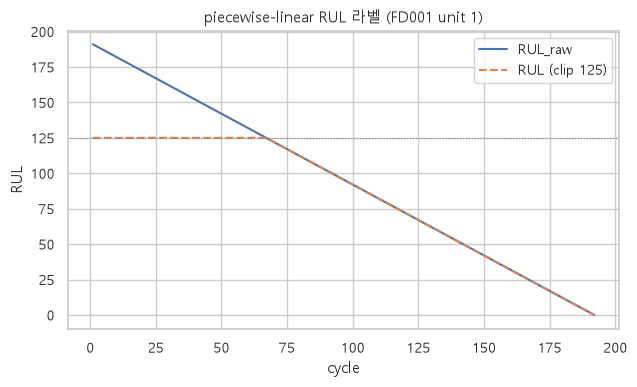

In [11]:
# F3. RUL piecewise-linear 라벨
one = add_labels(load_train("FD001")); one = one[one.unit==1]
plt.figure(figsize=(6.5,4))
plt.plot(one.cycle, one.RUL_raw, label="RUL_raw")
plt.plot(one.cycle, one.RUL, "--", label=f"RUL (clip {CLIP})")
plt.axhline(CLIP, color="gray", ls=":", lw=.8); plt.xlabel("cycle"); plt.ylabel("RUL")
plt.title("piecewise-linear RUL 라벨 (FD001 unit 1)"); plt.legend()
plt.tight_layout(); plt.savefig(FIG/"P3_rul_label.png", dpi=110, bbox_inches="tight"); plt.show()

## LSTM 병행 경로 — Sequence 전처리 (S1–S5 재사용, S6′ 분기)

윈도우 `L=30`, 좌측 패딩+마스킹. 입력 F = `z_`센서(n) + condition one-hot(다중조건 6).
train은 전 cycle을 샘플로, test는 각 엔진 마지막 윈도우 하나로 예측. rolling은 넣지 않는다(LSTM이 시간축 학습).

In [12]:
def make_windows(feat, L):           # feat:(T,F) -> W:(T,L,F), mask:(T,L)
    T, F = feat.shape
    p = np.vstack([np.zeros((L-1,F), feat.dtype), feat])
    W = sliding_window_view(p, (L,F))[:,0]
    idx = np.arange(T)[:,None]-(L-1)+np.arange(L)[None,:]
    return np.ascontiguousarray(W, np.float32), (idx>=0).astype(np.float32)

def seq_features(df, feat, multi):
    cols = [f"z_{s}" for s in feat]
    X = df[cols].to_numpy(np.float32)
    if multi:                        # condition one-hot (전역 6)
        oh = np.zeros((len(df), len(GLOBAL_CONDS)), np.float32)
        oh[np.arange(len(df)), df["condition_id"].map(COND_INDEX).to_numpy()] = 1.0
        X = np.hstack([X, oh])
    return X

def build_sequence(fd):
    tr = add_labels(load_train(fd)); te = add_labels(load_test(fd))
    feat = CLASS[fd]["feature"]; stats = fit_cond_stats(tr, feat)
    tr = apply_z(tr, feat, stats); te = apply_z(te, feat, stats)
    multi = tr["condition_id"].nunique() > 1
    # train: 모든 cycle 샘플
    Xs, ys, ms, us = [], [], [], []
    for u, g in tr.groupby("unit"):
        g = g.sort_values("cycle"); W, m = make_windows(seq_features(g, feat, multi), L_SEQ)
        Xs.append(W); ms.append(m); ys.append(g["RUL"].to_numpy(np.float32)); us.append(np.full(len(g), u))
    Xtr, ytr, mtr, utr = np.concatenate(Xs), np.concatenate(ys), np.concatenate(ms), np.concatenate(us)
    # test: 엔진별 마지막 윈도우
    Xt, mt = [], []
    for u, g in te.groupby("unit"):
        g = g.sort_values("cycle"); W, m = make_windows(seq_features(g, feat, multi), L_SEQ)
        Xt.append(W[-1]); mt.append(m[-1])
    Xte, mte = np.stack(Xt), np.stack(mt); true = load_rul(fd)
    return (Xtr,ytr,mtr,utr), (Xte,mte,true), Xtr.shape[2]

SEQ_MANIFEST={}
for fd in FD_LIST:
    (Xtr,ytr,mtr,utr),(Xte,mte,true),F = build_sequence(fd)
    # V11: 윈도우가 unit 경계 안 넘음 (마스킹된 유효 길이 <= 엔진 길이) — 구성상 보장, 형태 확인
    assert Xtr.shape[0]==len(ytr)==mtr.shape[0]==len(utr), f"[V11] {fd} 정렬"
    # V12: mask 정합 (0/1 만, 마지막 시점 항상 1)
    assert set(np.unique(mtr)).issubset({0.0,1.0}) and (mtr[:,-1]==1).all(), f"[V12] {fd} mask"
    np.savez_compressed(SEQ/f"{fd}_train.npz", X=Xtr, y=ytr, mask=mtr, unit=utr)
    np.savez_compressed(SEQ/f"{fd}_test.npz",  X=Xte, mask=mte, true_RUL=true)
    SEQ_MANIFEST[fd]={"L":L_SEQ,"F":int(F),"n_train":int(Xtr.shape[0]),"n_test":int(Xte.shape[0]),
                      "multi_condition":bool(CLASS[fd] and add_labels(load_train(fd))['condition_id'].nunique()>1)}
    print(f"{fd}: X_train {Xtr.shape} X_test {Xte.shape} F={F}  [V11,V12 OK]")
(SEQ/"seq_manifest.json").write_text(json.dumps(SEQ_MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print("\nsaved seq_manifest.json")

FD001: X_train (20631, 30, 15) X_test (100, 30, 15) F=15  [V11,V12 OK]


FD002: X_train (53759, 30, 23) X_test (259, 30, 23) F=23  [V11,V12 OK]


FD003: X_train (24720, 30, 16) X_test (100, 30, 16) F=16  [V11,V12 OK]


FD004: X_train (61249, 30, 23) X_test (248, 30, 23) F=23  [V11,V12 OK]

saved seq_manifest.json


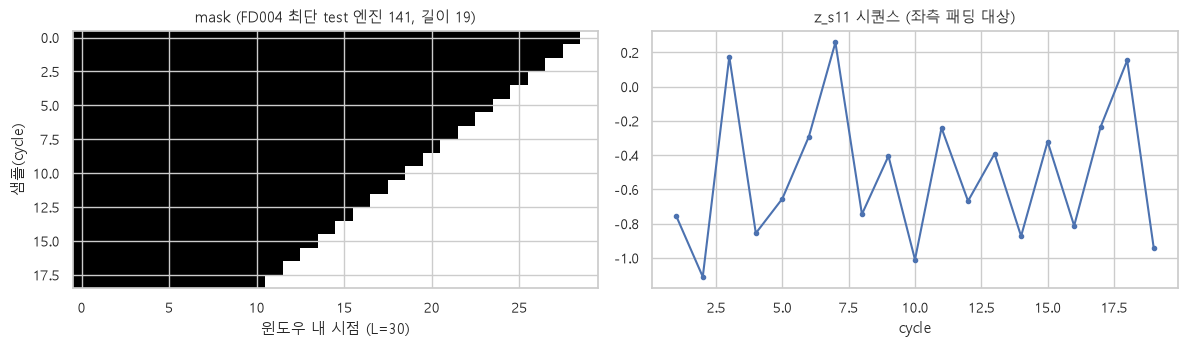

In [13]:
# F4. 윈도우/패딩 예시 — 짧은 test 엔진
te = add_labels(load_test("FD004")); feat = CLASS["FD004"]["feature"]
Lmin = te.groupby("unit")["cycle"].max(); short_u = Lmin.idxmin()
g = te[te.unit==short_u].sort_values("cycle")
tr = add_labels(load_train("FD004")); stats = fit_cond_stats(tr, feat)
g = apply_z(g, feat, stats)
W, m = make_windows(seq_features(g, feat, True), L_SEQ)
fig, ax = plt.subplots(1,2, figsize=(12,3.6))
ax[0].imshow(m, aspect="auto", cmap="Greys_r"); ax[0].set_title(f"mask (FD004 최단 test 엔진 {short_u}, 길이 {len(g)})")
ax[0].set_xlabel("윈도우 내 시점 (L=30)"); ax[0].set_ylabel("샘플(cycle)")
ax[1].plot(g["cycle"], g["z_s11"], marker="o", ms=3); ax[1].set_title("z_s11 시퀀스 (좌측 패딩 대상)")
ax[1].set_xlabel("cycle"); plt.tight_layout()
plt.savefig(FIG/"P4_lstm_padding.png", dpi=110, bbox_inches="tight"); plt.show()

## 통합 데이터셋 조립 — Unified Tabular (계획서 §5)

네 서브셋을 **합집합 17센서** 컬럼으로 정렬해 하나로 합친다.
- 없는 센서(FD001: s10·s16, FD003: s16)는 **NaN 유지** — "그 FD에 없음"은 정보다(LightGBM native 결측). 대치 금지.
- **`engine_id = FD_unit`** 신설 — raw `unit`은 FD 간 충돌(unit 1이 4개 FD 모두에 존재)하므로 통합 분리에 쓸 수 없다.
- **z 통계는 FD별 유지** — 고장모드가 달라 조건 기준선이 다를 수 있고, `dataset_id`가 정체성을 담당. pooled 통계는 A6 ablation.

In [14]:
UNION = sorted(set().union(*[set(CLASS[fd]["feature"]) for fd in FD_LIST]), key=lambda s: int(s[1:]))
def union_feature_cols(union):
    cols = list(union) + [f"z_{s}" for s in union]
    for w in (W_SHORT, W_LONG):
        for s in union:
            cols += [f"z_{s}_ma{w}", f"z_{s}_sd{w}"]
    for s in union:
        cols += [f"z_{s}_dl{W_LONG}", f"z_{s}_sl{W_LONG}"]
    return cols
UNION_FEATS = union_feature_cols(UNION)
assert set(UNION_FEATS) == set(MANIFEST["FD004"]["feature_cols"]), "합집합 컬럼 스펙 불일치"
print(f"합집합 열화가능 센서 {len(UNION)}개 → 통합 특징 {len(UNION_FEATS)}개")
print("  UNION:", UNION)

META_U = ["unit","cycle","dataset_id","condition_id","engine_id"]
def assemble_unified(split):
    parts = []
    for fd in FD_LIST:
        df = pd.read_csv(PROC / f"{split}_features_{fd}.csv")
        df["engine_id"] = fd + "_" + df["unit"].astype(str)
        cols = META_U + UNION_FEATS + (["RUL"] if split == "train" else [])
        parts.append(df.reindex(columns=cols))          # 없는 센서 컬럼 → NaN (정보로 유지)
    out = pd.concat(parts, ignore_index=True)
    out.to_csv(PROC / f"{split}_features_unified.csv", index=False)
    return out

uni_tr = assemble_unified("train"); uni_te = assemble_unified("test")
print(f"unified train {uni_tr.shape} | test {uni_te.shape}")

# ---- V13: 컬럼·행수·NaN 패턴 (FD 안에서 부분 NaN 금지 — 전부 있거나 전부 없거나) ----
EXP_NAN = {"FD001":16, "FD002":0, "FD003":8, "FD004":0}   # 없는 센서 수 × (raw1+z1+rolling6)
for fd in FD_LIST:
    sub = uni_tr[uni_tr.dataset_id == fd]
    full_nan = [c for c in UNION_FEATS if sub[c].isna().all()]
    part_nan = [c for c in UNION_FEATS if sub[c].isna().any() and not sub[c].isna().all()]
    assert len(full_nan) == EXP_NAN[fd] and not part_nan, f"[V13] {fd}: 전체NaN {len(full_nan)} 부분NaN {len(part_nan)}"
assert len(uni_tr) == 20631+53759+24720+61249, "[V13] train 행수"
assert len(uni_te) == 13096+33991+16596+41214, "[V13] test 행수"
print("[V13] 통합 컬럼·행수·NaN 패턴 OK — FD001:16 / FD003:8 / FD002·FD004:0 (부분 NaN 없음)")

# ---- V14: engine_id — unit은 FD 간 충돌하므로 engine_id로만 분리 ----
assert uni_tr.groupby("unit")["dataset_id"].nunique().max() == 4      # 충돌 전제 확인 (unit 1..100은 4개 FD에 존재)
assert uni_tr["engine_id"].nunique() == 709 and uni_te["engine_id"].nunique() == 707, "[V14] engine 수"
def unified_split(df, test_size=0.25, seed=SEED):    # FD별 층화 → 각 FD가 valid에 반드시 포함
    trs, vas = [], []
    for _, g in df.groupby("dataset_id"):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        i, j = next(gss.split(g, groups=g["engine_id"]))
        trs.append(g.iloc[i]); vas.append(g.iloc[j])
    return pd.concat(trs), pd.concat(vas)
tu, vu = unified_split(uni_tr)
assert not (set(tu.engine_id) & set(vu.engine_id)), "[V14] 통합 분리 겹침"
print(f"[V14] engine_id OK — 통합 train/valid 엔진 {tu.engine_id.nunique()}/{vu.engine_id.nunique()}, 겹침 0 (FD별 층화 분리)")

MANIFEST["unified"] = {"union_sensors": UNION, "n_features": len(UNION_FEATS),
    "nan_cols_per_fd": EXP_NAN, "engines_train": 709, "engines_test": 707,
    "rows_train": int(len(uni_tr)), "rows_test": int(len(uni_te)),
    "z_stats": "FD별 유지 (dataset_id가 정체성 담당; pooled는 A6 ablation)",
    "note": "NaN = '해당 FD에 센서 없음' 정보 — 대치 금지. 분리는 engine_id 기준."}
(PROC / "feature_manifest.json").write_text(json.dumps(MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print("feature_manifest.json 에 unified 항목 추가")

합집합 열화가능 센서 17개 → 통합 특징 136개
  UNION: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's20', 's21']


unified train (160359, 142) | test (104897, 141)


[V13] 통합 컬럼·행수·NaN 패턴 OK — FD001:16 / FD003:8 / FD002·FD004:0 (부분 NaN 없음)


[V14] engine_id OK — 통합 train/valid 엔진 531/178, 겹침 0 (FD별 층화 분리)
feature_manifest.json 에 unified 항목 추가


## 통합 Sequence — 채널 27 = z합집합(17) + condition one-hot(6) + dataset one-hot(4)

LSTM 통합 학습용. 없는 센서 채널은 **0으로 채운다** — z 공간에서 0 = "조건 평균"이라 중립이고,
dataset one-hot이 "이 FD엔 그 센서가 없다"를 구분하게 해 준다. (tabular의 NaN 유지와 달리 NN은 NaN 불가.)

In [15]:
DS_INDEX = {fd: i for i, fd in enumerate(FD_LIST)}
F_UNI = len(UNION) + len(GLOBAL_CONDS) + len(FD_LIST)      # 17 + 6 + 4 = 27

def seq_feats_unified(g, present, fd):
    X = np.zeros((len(g), len(UNION)), np.float32)          # 없는 센서 채널 = 0
    for j, s in enumerate(UNION):
        if s in present:
            X[:, j] = g[f"z_{s}"].to_numpy(np.float32)
    oc = np.zeros((len(g), len(GLOBAL_CONDS)), np.float32)
    oc[np.arange(len(g)), g["condition_id"].map(COND_INDEX).to_numpy()] = 1.0
    od = np.zeros((len(g), len(FD_LIST)), np.float32); od[:, DS_INDEX[fd]] = 1.0
    return np.hstack([X, oc, od])

Xtr_l, ytr_l, mtr_l, etr_l = [], [], [], []
Xte_l, mte_l, dte_l, true_l = [], [], [], []
for fd in FD_LIST:
    feat = CLASS[fd]["feature"]
    tr = add_labels(load_train(fd)); te = add_labels(load_test(fd))
    stats = fit_cond_stats(tr, feat)                        # FD별 z 통계 (train fit)
    tr = apply_z(tr, feat, stats); te = apply_z(te, feat, stats)
    for u, g in tr.groupby("unit"):
        g = g.sort_values("cycle")
        W, m = make_windows(seq_feats_unified(g, feat, fd), L_SEQ)
        Xtr_l.append(W); mtr_l.append(m)
        ytr_l.append(g["RUL"].to_numpy(np.float32)); etr_l.append(np.array([f"{fd}_{u}"] * len(g)))
    for u, g in te.groupby("unit"):
        g = g.sort_values("cycle")
        W, m = make_windows(seq_feats_unified(g, feat, fd), L_SEQ)
        Xte_l.append(W[-1]); mte_l.append(m[-1]); dte_l.append(fd)
    true_l.append(load_rul(fd))

Xtr_u = np.concatenate(Xtr_l); Xtr_l = None
ytr_u = np.concatenate(ytr_l); mtr_u = np.concatenate(mtr_l); etr_u = np.concatenate(etr_l)
Xte_u = np.stack(Xte_l); mte_u = np.stack(mte_l)
true_u = np.concatenate(true_l); dte_u = np.array(dte_l)

# ---- V15: 통합 텐서 shape · zero-fill 위치 · mask ----
assert Xtr_u.shape == (len(uni_tr), L_SEQ, F_UNI) and Xte_u.shape == (707, L_SEQ, F_UNI), "[V15] shape"
j10, j16 = UNION.index("s10"), UNION.index("s16")
is1 = np.char.startswith(etr_u.astype(str), "FD001_")
is3 = np.char.startswith(etr_u.astype(str), "FD003_")
assert np.all(Xtr_u[is1][:, :, [j10, j16]] == 0), "[V15] FD001 zero-fill (s10, s16)"
assert np.all(Xtr_u[is3][:, :, j16] == 0), "[V15] FD003 zero-fill (s16)"
assert set(np.unique(mtr_u)) <= {0.0, 1.0} and (mtr_u[:, -1] == 1).all(), "[V15] mask"
assert len(true_u) == 707 == len(dte_u), "[V15] test 라벨 정렬"

np.savez_compressed(SEQ / "unified_train.npz", X=Xtr_u, y=ytr_u, mask=mtr_u, engine=etr_u)
np.savez_compressed(SEQ / "unified_test.npz",  X=Xte_u, mask=mte_u, true_RUL=true_u, dataset=dte_u)
SEQ_MANIFEST["unified"] = {"L": L_SEQ, "F": int(F_UNI),
    "channels": "z_union(17) + condition_onehot(6) + dataset_onehot(4)",
    "n_train": int(Xtr_u.shape[0]), "n_test": int(Xte_u.shape[0]),
    "zero_fill": "없는 센서 채널=0 (z공간 0=조건 평균; dataset one-hot이 구분)"}
(SEQ / "seq_manifest.json").write_text(json.dumps(SEQ_MANIFEST, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"[V15] OK — unified X_train {Xtr_u.shape}  X_test {Xte_u.shape}  (F={F_UNI})")
print("saved unified_train.npz / unified_test.npz / seq_manifest.json(unified)")

[V15] OK — unified X_train (160359, 30, 27)  X_test (707, 30, 27)  (F=27)
saved unified_train.npz / unified_test.npz / seq_manifest.json(unified)


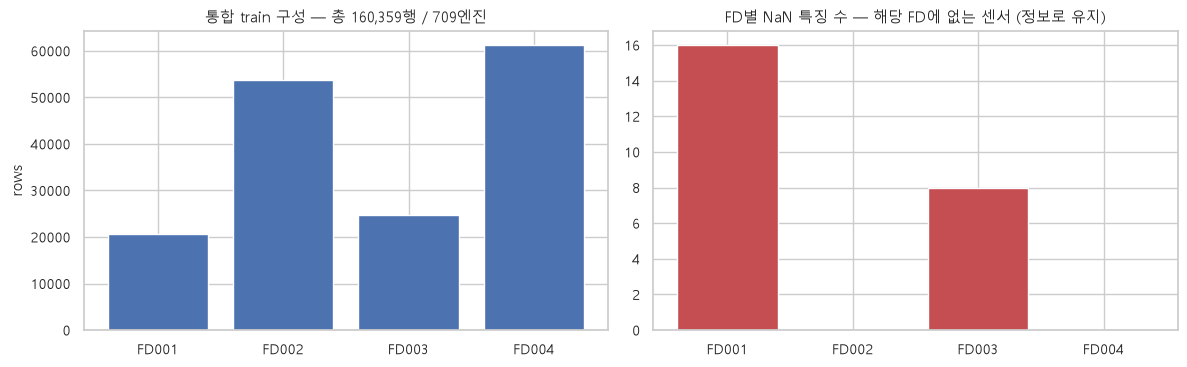

In [16]:
# P5. 통합 구성 개요
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
cnt = uni_tr["dataset_id"].value_counts().reindex(FD_LIST)
ax[0].bar(cnt.index, cnt.values, color="#4C72B0")
ax[0].set_title(f"통합 train 구성 — 총 {len(uni_tr):,}행 / 709엔진"); ax[0].set_ylabel("rows")
nan = pd.Series(EXP_NAN).reindex(FD_LIST)
ax[1].bar(nan.index, nan.values, color="#C44E52")
ax[1].set_title("FD별 NaN 특징 수 — 해당 FD에 없는 센서 (정보로 유지)")
plt.tight_layout(); plt.savefig(FIG / "P5_unified_overview.png", dpi=110, bbox_inches="tight"); plt.show()

## 요약

| 산출물 | 경로 |
|---|---|
| Tabular (FD별) | `data/processed/{train,test}_features_{FD}.csv` |
| **Tabular (통합)** | `data/processed/{train,test}_features_unified.csv` — 합집합 17 정렬 + `engine_id` |
| Sequence (FD별) | `data/processed/seq/{FD}_{train,test}.npz` |
| **Sequence (통합)** | `data/processed/seq/unified_{train,test}.npz` — F=27 (z 17 + cond 6 + ds 4) |
| Manifest | `feature_manifest.json`(unified 포함), `seq/seq_manifest.json`(unified 포함) |
| 그림 | `reports/figures/preprocessing/P1–P5.png` |

검증 통과: V1(조건수) V2(퇴화) V3(z-clip) V4(NaN) V5(누수컬럼) V6(엔진분리) V8(미래미사용) V9(RUL범위)
V10(조건지시자 제외) V11(시퀀스정렬) V12(mask) **V13(통합 NaN 패턴) V14(engine_id) V15(통합 텐서)**.

다음(03): FD별 + 통합 RUL 회귀 → ablation A0–A10 (A6: 합집합 vs 교집합, pooled z 통계), FD별 분리 평가.